# 5 · Lab: Hong–Ou–Mandel Interference

**Simulation lab, part 1 · Wednesday July 29, 9:00–10:00 · work in pairs**

Today you run linear-optical experiments on a simulated photonic quantum processor, using **Perceval** [Heurtel2023] — the same framework used to program Quandela's real photonic quantum computers. The physics star of this session is the **Hong–Ou–Mandel (HOM) effect** [Hong1987]: two indistinguishable photons meeting on a beamsplitter *always leave together*.

### Learning objectives

1. build and sample a linear-optical circuit in Perceval,
2. predict and verify the two-photon output of a 50:50 beamsplitter,
3. simulate a **HOM dip** and extract its visibility,
4. demonstrate **NOON-state super-resolution**.

*Review reading: [Bouchard2021] in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("perceval") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "perceval-quandela"])

import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
print("perceval", pcvl.__version__)

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

perceval 1.2.4


## The machine behind the SDK

<img src="../figures/photonic_chip.jpg" height="195" align="right" style="margin-left:14px" alt="A photonic integrated chip held with tweezers (M. King/NIST, public domain)"/>

Perceval is not a pedagogical toy — it is the programming interface of **Quandela**'s photonic quantum computers [Maring2024]. And that machine is this course, assembled end to end (sketch below):

1. **The source is Lecture 3's single emitter, industrialized**: one InGaAs quantum dot in a micropillar cavity at 4 K. Purcell enhancement (*that* Purcell — the 1946 spontaneous-emission factor, by the same man who rescued HBT in 1956) funnels the emission into a single collection mode, and pulsed excitation at an 80 MHz clock turns the dot into a metronome of single photons. That sentence compresses twenty years of work: Santori et al. demonstrated the first quantum-dot two-photon interference in 2002 — visibility 0.81, with only a trickle of photons escaping the chip [Santori2002]. Three problems separated that demo from a computer: **extraction** (a dot in bulk radiates into the semiconductor; a few percent escape), **distinguishability** (charge noise and phonons jitter the emission frequency between shots), and simply **finding the dot** (self-assembled dots grow at random positions). The fixes were pioneered in Pascale Senellart's group at CNRS-C2N: grow the pillar *around* a chosen dot by in-situ optical lithography, let the Purcell effect force fast emission into one cavity mode before the environment can dephase it, pin the charge state with an electrical gate, and excite resonantly — near-unity indistinguishability at high brightness [Somaschi2016]. (Excitation has since evolved: strict resonance fluorescence needs crossed-polarizer pump rejection, which eats half the polarized photons; today's machines — Ascella included — use *near-resonant LA-phonon-assisted* excitation instead: detune the pulse slightly blue and let an acoustic phonon bridge the gap, so the pump is rejected spectrally and the emission stays polarized [Maring2024]. The third scheme in the field, two-photon excitation of the *biexciton*, is the workhorse of entangled-pair sources rather than of single-photon streams.) **Quandela is that lab spun into a company** (2017, Paris) — the machines Perceval programs, up to Ascella and beyond [Maring2024].

> **The collection-efficiency ladder** — how you actually get the photons *out* (each rung is one physics idea):
> 1. **Bare dot in bulk GaAs: ~2%.** The semiconductor has $n \approx 3.5$; total internal reflection traps everything outside a narrow escape cone — the fraction leaving the top surface is $\sim 1/4n^2$. This single number is why "grow a great emitter" is not enough.
> 2. **Solid immersion lens: ~10%.** An index-matched hemisphere glued on top widens the escape cone — cheap, broadband, the standard first fix.
> 3. **Micropillar cavity: >90% into *one mode*.** DBR mirrors above and below make a cavity; the Purcell factor $F_P \propto Q/V$ makes the dot emit into the cavity mode with probability $\beta = F_P/(F_P+1)$ — and that mode leaks through the top mirror as a near-Gaussian beam, made for a fiber. Geometry cousins with the same job: photonic nanowires and bullseye (circular Bragg) gratings.
> 4. **Deterministic matching.** The cavity only helps if the dot sits at its antinode (in-situ lithography, ±50 nm) *and* on its resonance (temperature/electrical tuning) — otherwise rung 3 collapses back to rung 1.
> 5. **The last hop: into the fiber.** Mode-match the output beam to a single-mode fiber; the record fiber-coupled brightness for a coherent single-photon stream is ≈57% [Tomm2021]. Every following experiment inherits this number as a factor $\eta$ — Exercise 4 shows what that does to $N$-photon protocols.
2. **A demultiplexer** — fast optical switches — carves the temporal photon train into $N$ parallel spatial modes. In Lecture 3's detector-axis language: a time → space conversion.
3. **The processor is a photonic chip**: a mesh of Mach–Zehnder interferometers with thermo-optic phase shifters that can realize *any* unitary on the modes. Every `pcvl.BS` you write today compiles to one of those MZIs. (The numbers that rule chip design: waveguide propagation loss ~0.1–0.5 dB/cm and a fraction of a percent per component — harmless for one MZI, decisive for a deep mesh: an $N$-photon experiment pays every loss to the $N$-th power, Exercise 4's $\eta^N$ lesson as daily engineering reality.) (Pictured: a photonic integrated chip — this one from NIST — showing the scale; the waveguide circuit lives on a few mm².)
4. **SNSPDs** (Lecture 3's detector of choice) click at the output ports.

The spec sheet of such a machine is written in this course's units: single-photon purity $1 - g^{(2)}(0) > 99\%$ — certified exactly as in yesterday's hands-on — and pairwise photon **indistinguishability** $\gtrsim 90\%$ — certified by *today's* measurement, the HOM dip. On Ascella (6 photons in 12 modes, cloud-accessible), that translated to one-qubit gate fidelities of 99.6% and two-qubit 93.8% [Maring2024]. When Exercise 2 hands you `NoiseModel(indistinguishability=...)`, you are dialing in precisely the imperfection that limits these machines.

*(See [Quandela's site](https://www.quandela.com/) for the real hardware, cryostats and all.)*

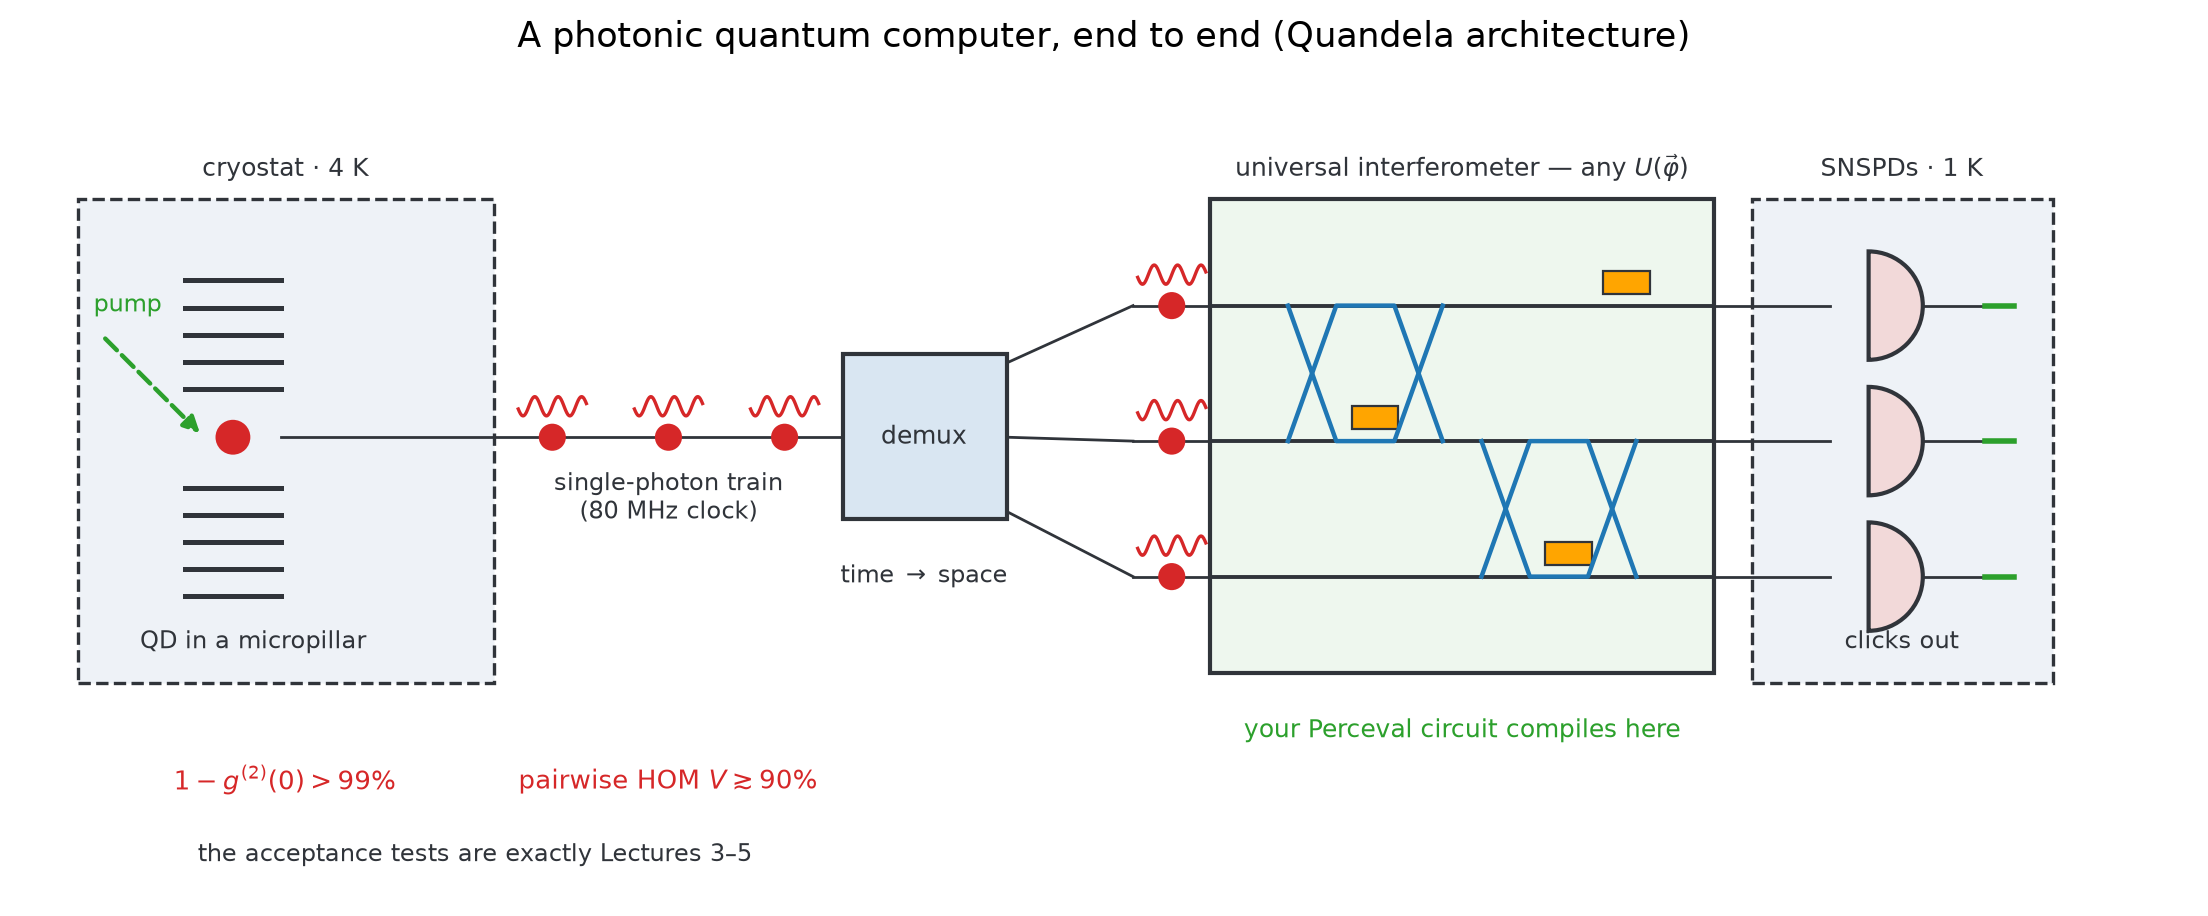

In [2]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.pqc_architecture()

## Perceval in 10 minutes

Perceval describes experiments the way an optics lab does:

| concept | Perceval object | example |
|---|---|---|
| photons entering the chip | `BasicState` | `pcvl.BasicState([1, 1])` — one photon in each of 2 modes |
| the optical circuit | `Circuit` + components | `pcvl.BS()` (beamsplitter), `pcvl.PS(phi)` (phase shifter) |
| the machine that runs it | `Processor` | `pcvl.Processor("SLOS", circuit)` |
| taking data | `Sampler` | `sampler.probs()` or `sampler.sample_count(N)` |

A *mode* is one path on the chip (it could also be a polarization or a time bin). `|1,1⟩` means "one photon in the top mode, one in the bottom mode". Let's start with the simplest quantum experiment there is: **one photon on a beamsplitter.**

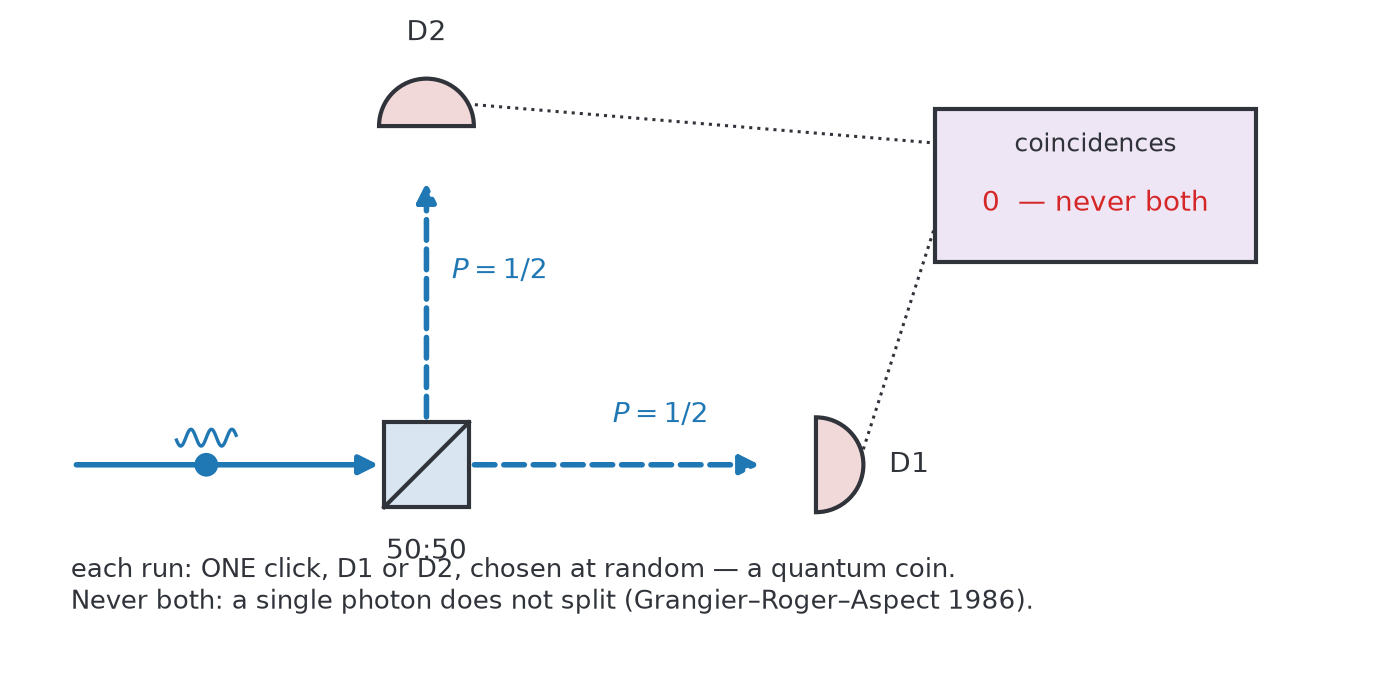

In [3]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.single_photon_bs()

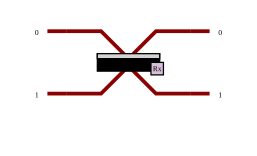

In [4]:
# One photon, one 50:50 beamsplitter.
circuit = pcvl.Circuit(2) // pcvl.BS()      # 2 modes, one beamsplitter
pcvl.pdisplay(circuit)

In [5]:
processor = pcvl.Processor("SLOS", circuit)    # SLOS = exact simulation backend
processor.with_input(pcvl.BasicState([1, 0]))  # photon enters the top mode
processor.min_detected_photons_filter(1)       # keep events with >= 1 detected photon

sampler = pcvl.algorithm.Sampler(processor)
probs = sampler.probs()["results"]
print("exact output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

# ... and what actual repeated single-shot measurements look like:
counts = sampler.sample_count(1000)["results"]
print("\n1000 samples (clicks!):")
for state, c in counts.items():
    print(f"  {state}: {c}")

exact output probabilities:
  |0,1>: 0.500
  |1,0>: 0.500

1000 samples (clicks!):
  |1,0>: 516
  |0,1>: 484


50/50 — each *single* photon takes one output or the other at random. Name that randomness carefully: it is **partition noise**, not yet Monday's shot noise — the input $|1\rangle$ has *no* photon-number fluctuation at all; the randomness lives in *where* the photon goes (equivalently: in the vacuum entering the unused port — the same vacuum that sets LIGO's shot noise). Chop a bright coherent beam into its photons and this partition randomness, summed over the stream, is what *builds* the Poissonian shot noise of Monday: binomial thinning keeps Poisson Poisson. And note the fine print: as a click record this proves nothing quantum — a classical coin would explain the data.

## One photon interferes with itself (Taylor 1909)

Before the two-photon magic, re-run the **oldest quantum-optics experiment there is**. In 1909, G.I. Taylor — on Thomson's suggestion — photographed diffraction fringes using light attenuated until, by his estimate, at most one quantum was in flight at a time (exposure: three months; light level: "a candle burning at a distance slightly exceeding a mile") [Taylor1909]. The fringes survived: *a single photon interferes with itself.*

Our chip version of "two slits" is the **Mach–Zehnder interferometer** — an instrument with its own history: Ludwig Zehnder built it in 1891, and Ludwig Mach (Ernst Mach's son) refined it a year later [Zehnder1891, Mach1892], both for measuring refractive indices of gases. Its superpower over Michelson's design: the two paths are *separated*, so a sample — or a phase shifter — can sit in one arm alone. That is why it became the unit cell of every photonic chip, including the one you are programming right now. The recipe: split one photon, phase-shift one path by $\varphi$, recombine:

> **"Wait — Monday said a single photon has *no phase*!"** Correct, and there is no contradiction — but the distinction is worth engraving. What $|1\rangle$ lacks is a *field* phase: $\langle\hat E\rangle = 0$, the Wigner ring is rotationally symmetric, no clock is attached to the photon. What the MZI reads out is something else entirely: after the first beamsplitter the photon is in a **superposition of two paths**, $(|1,0\rangle + i\,|0,1\rangle)/\sqrt2$, and $\varphi$ shifts the **relative phase between the two amplitudes** of that superposition — exactly as physical as the relative phase between spin-up and spin-down on a Bloch sphere. One photon, two amplitudes, one relative phase: that is what interferes. And yes — it is the *optical* phase scale: $\varphi = 2\pi\Delta L/\lambda$, so the fringe period in path length is exactly the wavelength, as classical as it looks. The wavelength lives in the *mode* the photon occupies; what $|1\rangle$ withholds is only the absolute clock — and the MZI never asks for it, because it compares the photon with itself. (Exercise 4's twist: an $N$-photon NOON state shares one effective wavelength $\lambda/N$.) (The phase you can *not* access this way is the absolute one: put equal phase shifters in *both* arms and nothing whatsoever changes.)

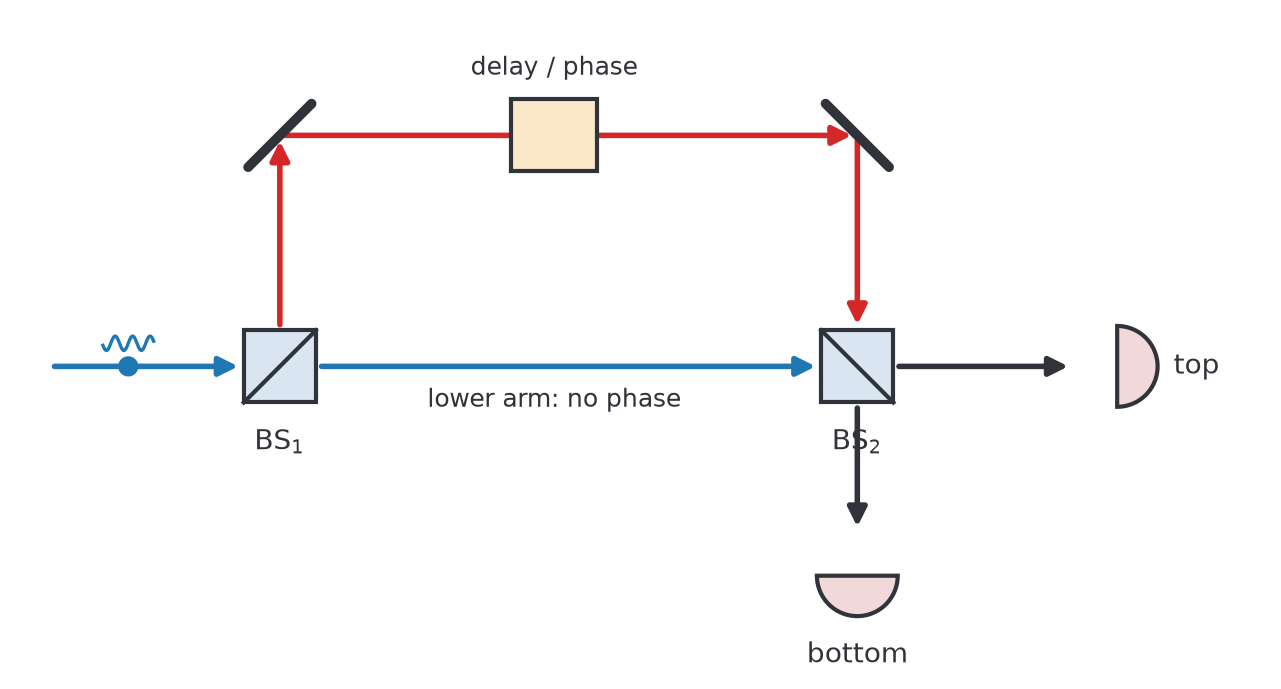

In [6]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.mzi_sketch()

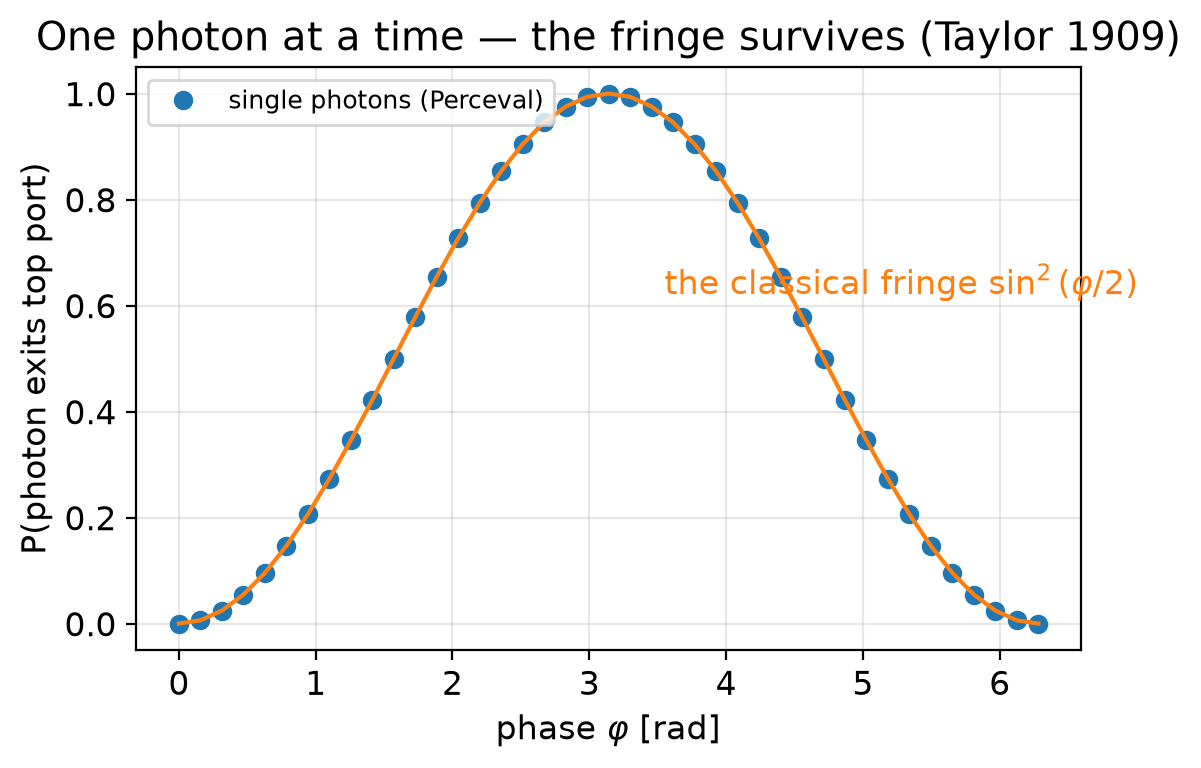

In [7]:
# Taylor 1909, integrated-optics edition: single-photon MZI fringes.
def mzi(phi: float) -> pcvl.Circuit:
    """Mach-Zehnder interferometer: BS - phase phi in the top arm - BS."""
    return pcvl.Circuit(2) // pcvl.BS() // (0, pcvl.PS(phi)) // pcvl.BS()

phis = np.linspace(0, 2 * np.pi, 41)
p_top = []
for phi in phis:
    proc = pcvl.Processor("SLOS", mzi(phi))
    proc.with_input(pcvl.BasicState([1, 0]))       # ONE photon
    proc.min_detected_photons_filter(1)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_top.append(res.get(pcvl.BasicState([1, 0]), 0.0))

plt.plot(phis, p_top, "o", label="single photons (Perceval)")
plt.plot(phis, np.sin(phis / 2) ** 2, "-",
         label=None)  # named by the annotation below
plt.xlabel(r"phase $\varphi$ [rad]")
plt.ylabel("P(photon exits top port)")
plt.title("One photon at a time — the fringe survives (Taylor 1909)")
plt.annotate(r"the classical fringe $\sin^2(\varphi/2)$",
             (3.55, 0.62), color="tab:orange")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Each run detects **one** click, top *or* bottom — never half a photon in each. Only the *statistics* over many runs trace the fringe, and it follows the classical intensity formula exactly. Single-photon ("first-order") interference reproduces classical interference — nothing here needs photons at all, as the wave theory happily explains this experiment. Hold that thought for Exercise 3.

## The HOM effect: now send in TWO photons

The experiment has a birthplace: **Leonard Mandel's lab in Rochester, 1987** — the same Mandel whose sodium-beam antibunching opened Tuesday's story. Chung Ki Hong and Zhe-Yu Ou, then Mandel's student and postdoc, were not hunting a philosophy demonstration; they wanted to *measure the time interval between two photons* far below any detector's resolution — and realized that two indistinguishable photons meeting on a beamsplitter betray their relative delay by how often they leave together [Hong1987]. Two pages in PRL; today it is the benchmark every photon source on the planet is graded by (the wrap-up returns to this).

Input $|1,1\rangle$ — one photon in each input port, perfectly indistinguishable. Classical intuition says: each picks a side independently, so 50% of the time they exit on *different* sides (a coincidence).

Quantum mechanics says: the two paths to a coincidence — *both transmit* and *both reflect* — are indistinguishable processes, so their **amplitudes** add. For a 50:50 beamsplitter they cancel *exactly*:

$$P_{\rm coinc} = |t^2 + r^2|^2 = \left|\tfrac12 + \left(-\tfrac12\right)\right|^2 = 0 .$$

(The minus sign is the beamsplitter's unitarity speaking: the reflected amplitude is $r = i/\sqrt2$ — a phase $i$ — and $i^2 = -1$, so $r^2 = -\tfrac12$.)

### What "indistinguishable" actually means — and how visibility measures it

The cancellation above assumed the two photons agree in *every* mode label — Tuesday's four axes: arrival **time**, **frequency**, **polarization**, spatial **mode**. If any label differs, the two coincidence paths become distinguishable *in principle*, and amplitudes stop adding — probabilities do. The continuous knob in between is the **indistinguishability** $\mathcal{I} = |\langle\psi_1|\psi_2\rangle|^2$, the squared overlap of the two single-photon wavepackets, and the coincidence rate interpolates linearly: $P_{\rm coinc} = \tfrac12(1-\mathcal{I})$ — from quantum silence ($\mathcal{I} = 1$) to the classical coin flip ($\mathcal{I} = 0$).

The *measured* face of $\mathcal{I}$ is the **dip visibility** $V = (P_{\rm wings} - P_{\rm min})/P_{\rm wings}$: for an ideal $|1,1\rangle$ input, $V = \mathcal{I}$ at zero delay. Two numbers to carry out of today: $V > 1/2$ is the **quantum certificate** — no classical field can beat one-half (Exercise 3's interlude has the fine print) — and $V$ is *the* datasheet number of a single-photon source (the pairwise HOM $V \gtrsim 90\%$ on the architecture sketch above). Exercise 2 measures it.

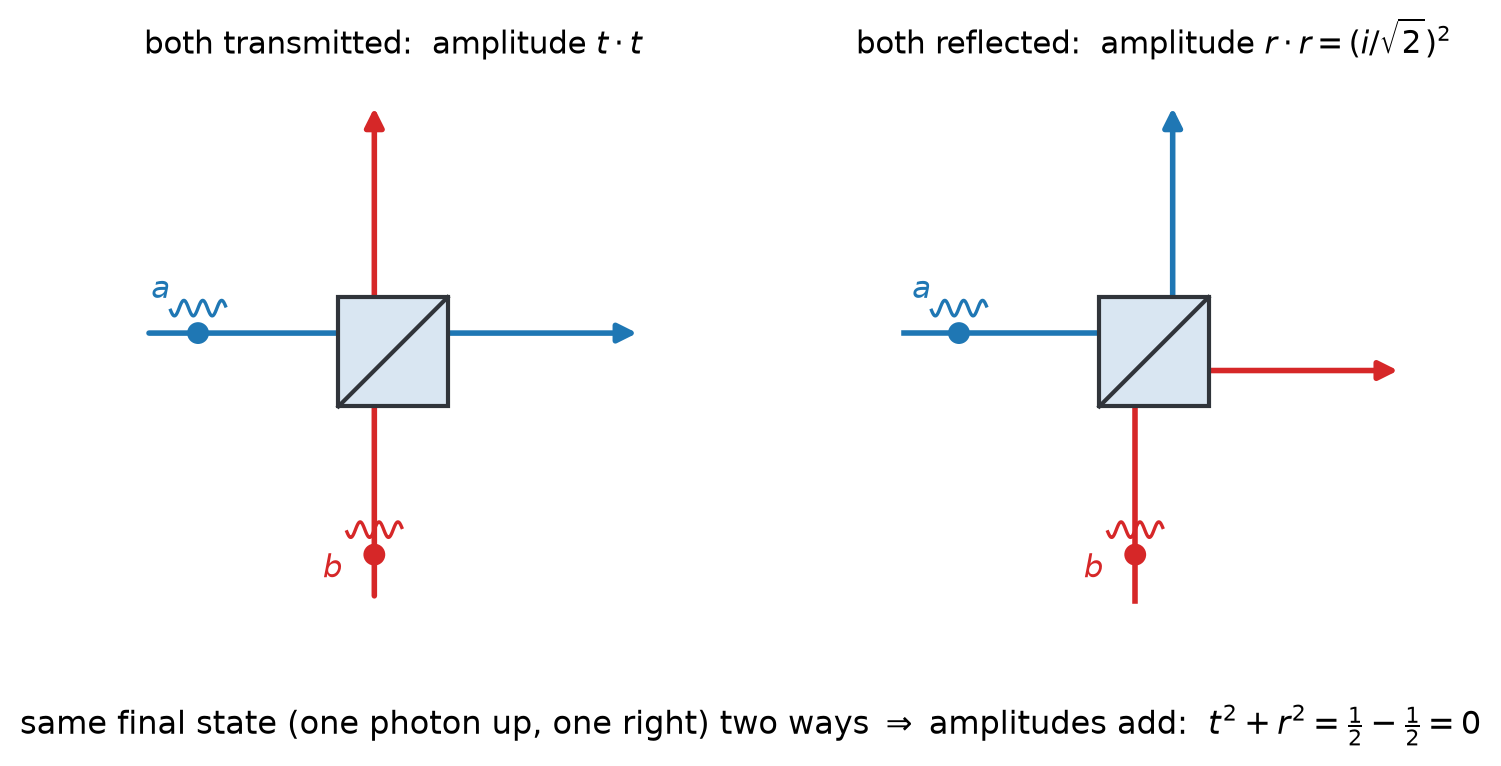

In [8]:
sketches.hom_amplitudes()

In [9]:
# HOM: two indistinguishable photons on the 50:50 beamsplitter.
processor = pcvl.Processor("SLOS", circuit)
processor.with_input(pcvl.BasicState([1, 1]))
processor.min_detected_photons_filter(2)

probs = pcvl.algorithm.Sampler(processor).probs()["results"]
print("two-photon output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

two-photon output probabilities:
  |0,2>: 0.500
  |2,0>: 0.500


**The photons bunch:** always $|2,0\rangle$ or $|0,2\rangle$, *never* $|1,1\rangle$. No coincidences — this is not interference of intensities (it survives any phase between the inputs), it is interference of **two-photon amplitudes**. It only happens because the photons are fully indistinguishable bosons.

## Exercise 1 · Unbalancing the beamsplitter

*In the session: watch and discuss — predict each plot before it appears. The fill-in version to rebuild this yourself is at the bottom of the notebook; the worked cell here is its solution.*


For a beamsplitter with reflectivity $R$ (and $T = 1-R$), the coincidence probability for $|1,1\rangle$ input is

$$P_{\rm coinc}(R) = (T - R)^2 = (1 - 2R)^2 .$$

**Task:** verify this with Perceval. The sweep and plot are wired in the scaffold — your inputs: the $R$ grid, and the prediction line (translate the formula above into code). Then answer: at which $R$ do coincidences vanish completely, and why *there*?

*API hint:* a beamsplitter with a given reflectivity is `pcvl.BS(theta=pcvl.BS.r_to_theta(R))`.

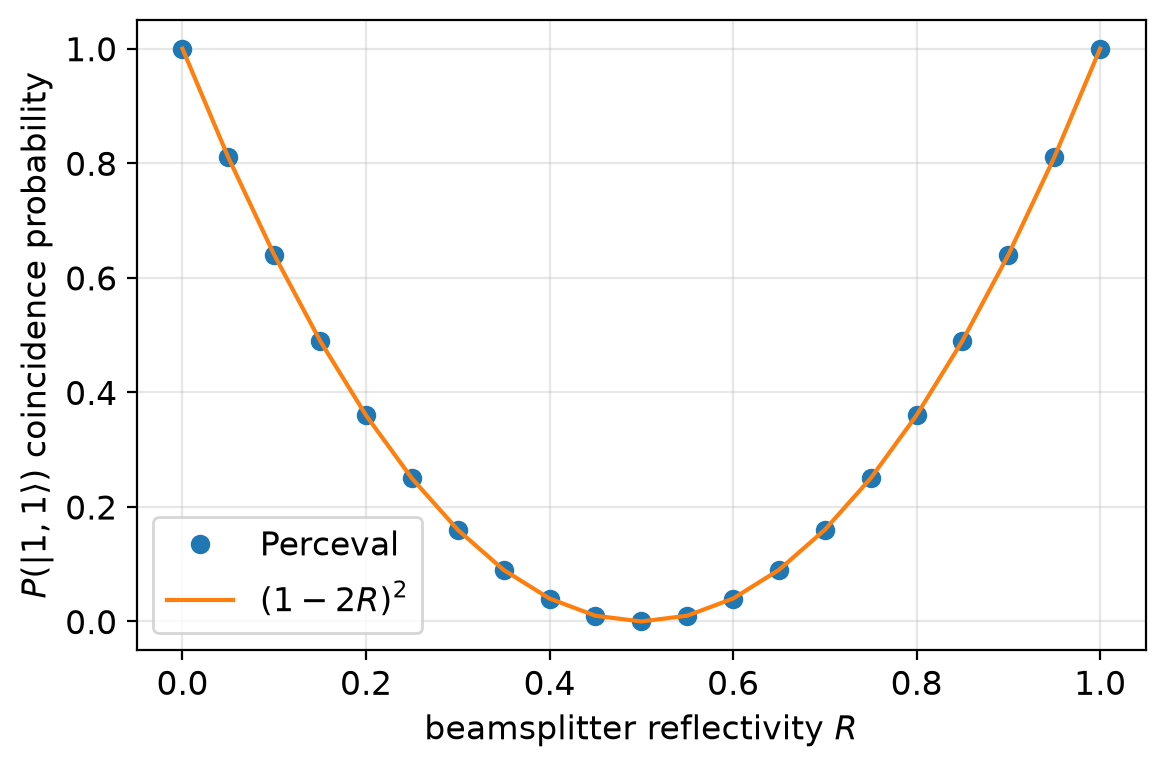

In [10]:
# Worked - Exercise 1 (the fill-in version lives at the bottom)
R_values = np.linspace(0, 1, 21)
p_coinc = []
for R in R_values:
    c = pcvl.Circuit(2) // pcvl.BS(theta=pcvl.BS.r_to_theta(R))
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(R_values, p_coinc, "o", label="Perceval")
plt.plot(R_values, (1 - 2 * R_values) ** 2, "-", label="$(1-2R)^2$")
plt.xlabel("beamsplitter reflectivity $R$")
plt.ylabel(r"$P(|1,1\rangle)$ coincidence probability")
plt.legend(); plt.tight_layout(); plt.show()

## Exercise 2 · The HOM dip

*In the session: watch and discuss — predict each plot before it appears. The fill-in version to rebuild this yourself is at the bottom of the notebook; the worked cell here is its solution.*


In the lab you can't just declare photons indistinguishable — you *tune* their overlap, classically, by sliding a delay line: photons that arrive at very different times are perfectly distinguishable (no interference), photons that arrive simultaneously interfere fully. Scanning the delay $\delta\tau$ traces out the famous **HOM dip** in the coincidence rate.

For photons with Gaussian wavepackets of coherence time $\tau_c$, the *indistinguishability* (mode overlap squared) is

$$\mathcal{I}(\delta\tau) = e^{-(\delta\tau/\tau_c)^2},$$

and the coincidence probability at a 50:50 beamsplitter becomes

$$P_{\rm coinc}(\delta\tau) = \tfrac12\left(1 - \mathcal{I}(\delta\tau)\right).$$

In Perceval, partial distinguishability is a property of the photon *source*, set through the noise model:

```python
processor = pcvl.Processor("SLOS", circuit,
                           noise=pcvl.NoiseModel(indistinguishability=I))
```

**Task:** the noise-model sweep (part 1) is wired in the scaffold. Your inputs:
1. check the wired part confirms $P = (1-\mathcal{I})/2$;
2. fill in the **Gaussian mapping** $\mathcal{I}(\delta\tau)$ from above — that single line turns the overlap curve into the HOM dip;
3. read off the **visibility** $V = \frac{P_{\max} - P_{\min}}{P_{\max}}$ that the scaffold prints. What is $V$ for perfectly indistinguishable photons? What would $V = 0.5$ tell you about a photon-pair source?

> **The dip in a real lab.** Your x-axis is a *motorized delay stage*: the dip is $\sim c\tau_c$ wide — tens of µm of travel (Hong, Ou and Mandel's: 16 µm at half depth) — so you step in µm and count seconds per point, at typical SPDC rates of $10^4$–$10^5$ singles/s and $10^1$–$10^3$ coincidences/s. What eats visibility, in the order a lab debugs it:
> 1. **spatial overlap** — the standard cure is brutal and elegant: couple *both* photons into one single-mode fiber and let the fiber *be* the mode (Hong 1987 used pinholes instead, and the paper names imperfect pinhole overlap as its visibility limit);
> 2. **polarization** — one waveplate away;
> 3. **spectral overlap** — matched interference filters (which also set $\tau_c$, i.e. your dip width);
> 4. **beamsplitter imbalance** — caps the dip at $2RT/(R^2+T^2)$: Hong's $R/T = 0.95$ cost all of 0.1% — rarely the culprit;
> 5. **multi-pair emission** — pump too hard and a second pair fills the dip: SPDC emits $n$ pairs with geometric statistics, and the odds of a double, $P(2)/P(1) = \lambda^2$, grow *linearly with pump power* — so every factor of brightness costs the same factor of contrast; the source's own $g^{(2)}$ sets the visibility ceiling (the next hour's design-challenge trade-off, met from the other side);
> 6. **accidentals** — subtracted, and *declared*: quote raw $V$ and corrected $V$, never silently the better one.

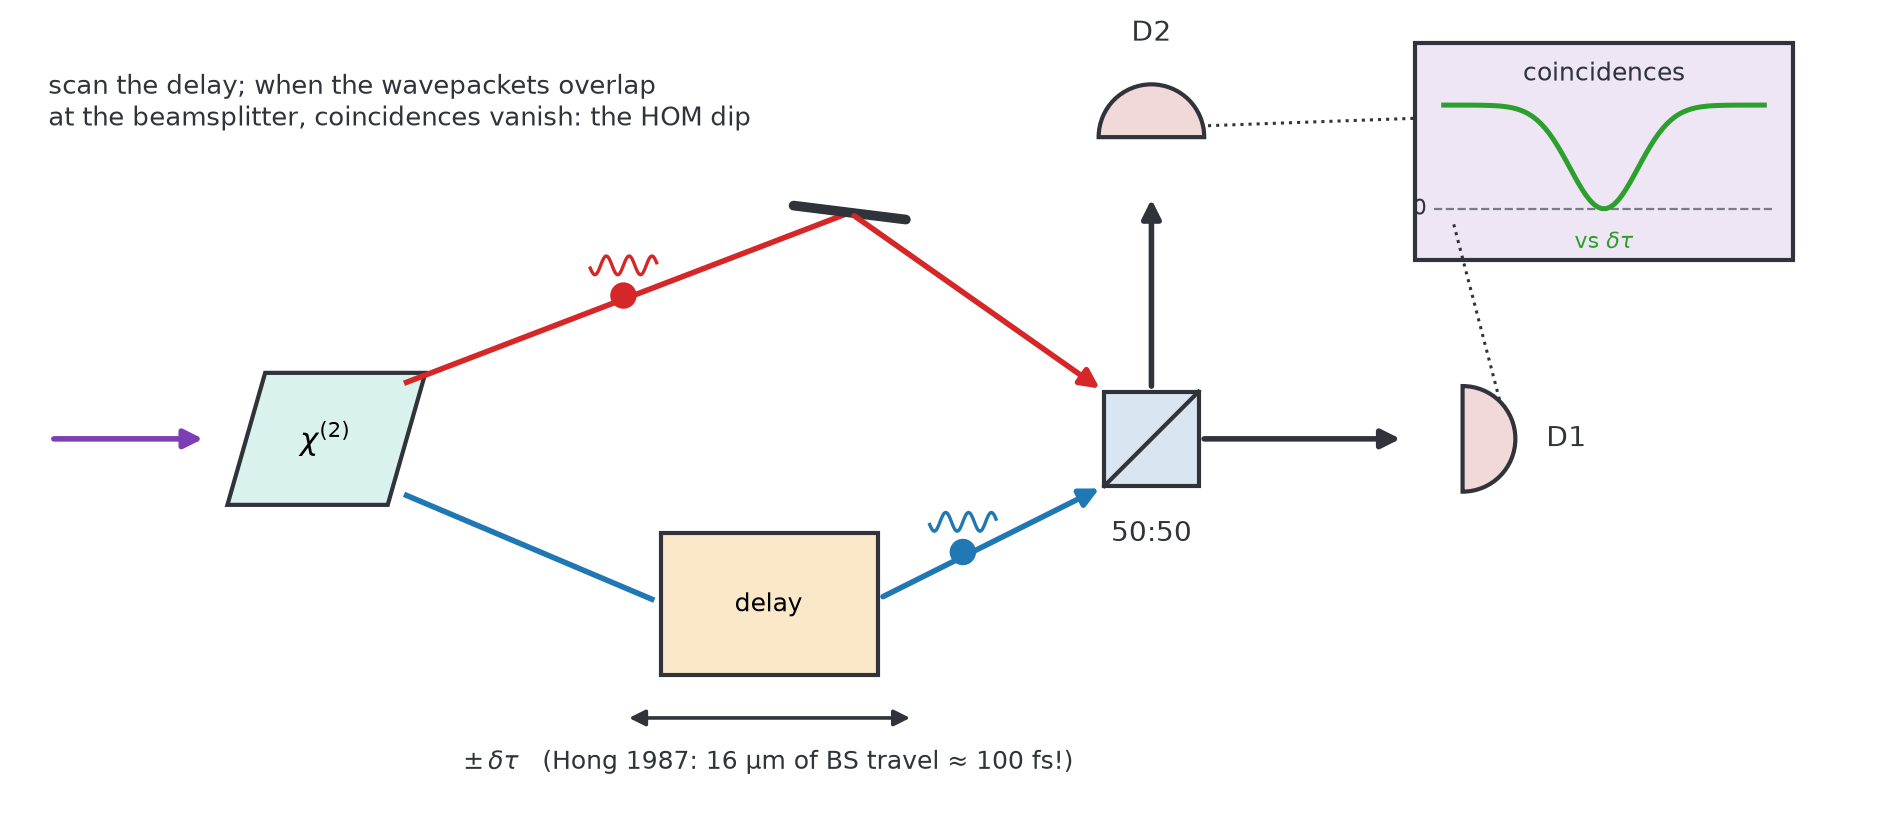

In [11]:
sketches.hom_dip_setup()

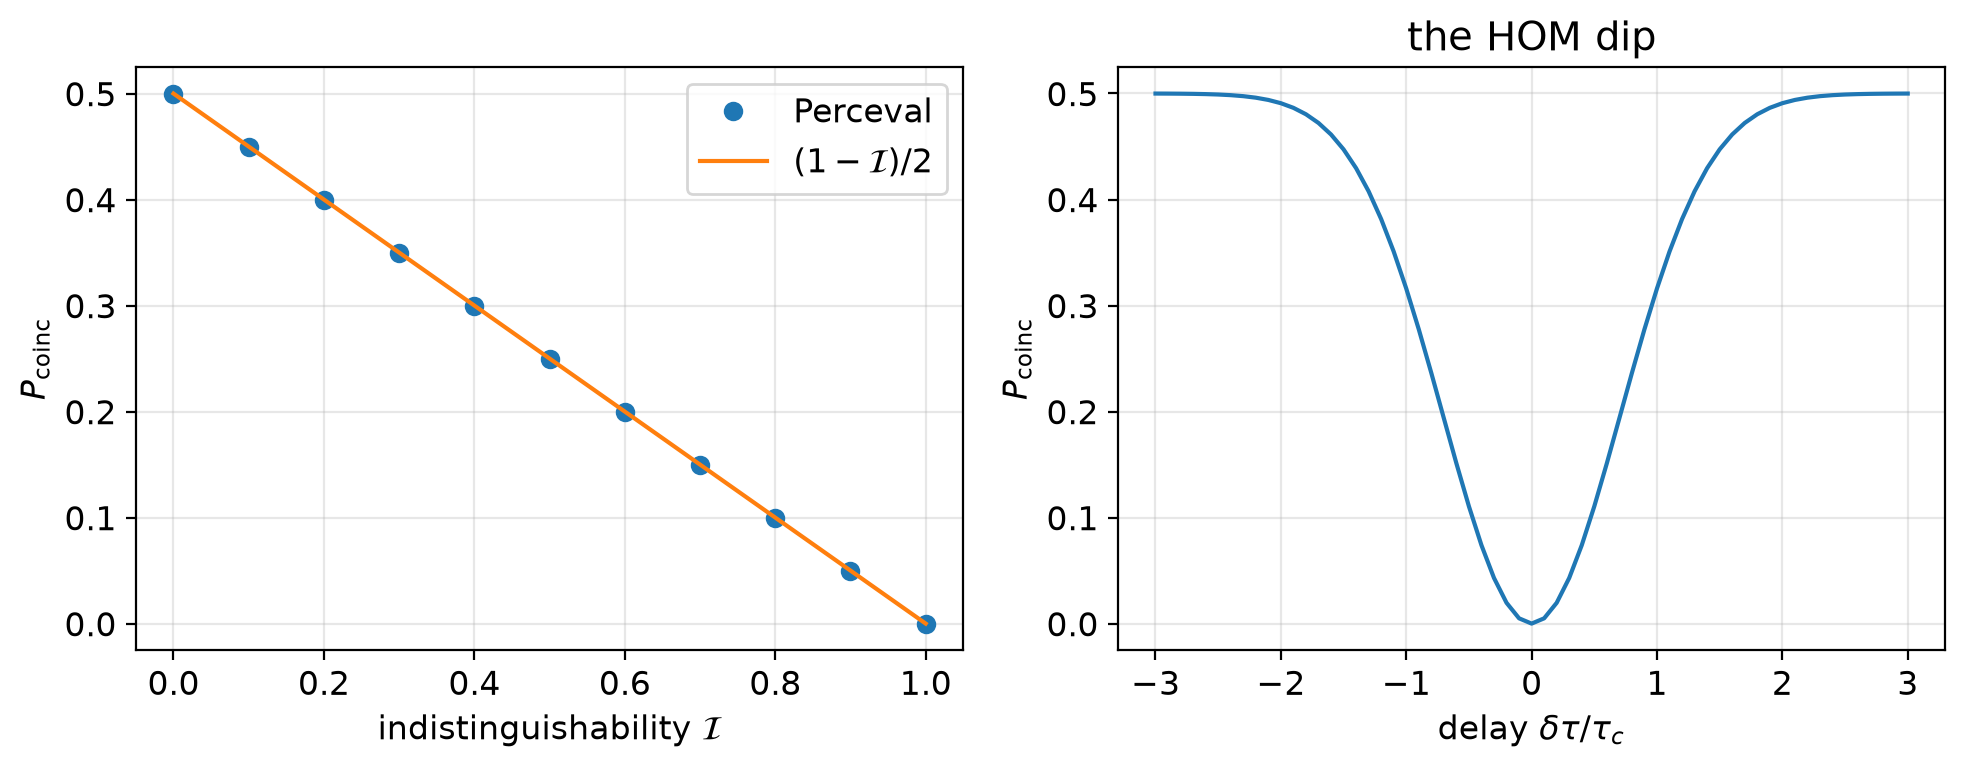

dip visibility V = 1.000
V = 1 for perfectly indistinguishable photons;
V = 0.5 is the classical limit for intensity-correlated fields -
a source with V = 0.5 shows no quantum interference at all.


In [12]:
# Worked - Exercise 2 (the fill-in version lives at the bottom)
circuit = pcvl.Circuit(2) // pcvl.BS()

# (1) coincidences vs indistinguishability
I_values = np.linspace(0, 1, 11)
p_coinc = []
for I in I_values:
    proc = pcvl.Processor("SLOS", circuit,
                          noise=pcvl.NoiseModel(indistinguishability=I))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(sum(p for st, p in res.items()
                       if st[0] == 1 and st[1] == 1))
p_coinc = np.array(p_coinc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(I_values, p_coinc, "o", label="Perceval")
ax1.plot(I_values, (1 - I_values) / 2, "-", label=r"$(1-\mathcal{I})/2$")
ax1.set_xlabel(r"indistinguishability $\mathcal{I}$")
ax1.set_ylabel(r"$P_{\rm coinc}$")
ax1.legend()

# (2) the dip vs delay, Gaussian wavepackets
delay = np.linspace(-3, 3, 61)                    # delta_tau / tau_c
I_of_delay = np.exp(-delay**2)
# interpolate the simulated P(I) onto the delay axis:
p_dip = np.interp(I_of_delay, I_values, p_coinc)
ax2.plot(delay, p_dip, "-")
ax2.set_xlabel(r"delay $\delta\tau / \tau_c$")
ax2.set_ylabel(r"$P_{\rm coinc}$")
ax2.set_title("the HOM dip")
plt.tight_layout(); plt.show()

# (3) visibility
V = (p_dip.max() - p_dip.min()) / p_dip.max()
print(f"dip visibility V = {V:.3f}")
print("V = 1 for perfectly indistinguishable photons;")
print("V = 0.5 is the classical limit for intensity-correlated fields -")
print("a source with V = 0.5 shows no quantum interference at all.")

## Exercise 3 · Two-photon interference has no phase

*In the session: watch and discuss — predict each plot before it appears. The fill-in version to rebuild this yourself is at the bottom of the notebook; the worked cell here is its solution.*


The claim from the whiteboard: HOM is interference of *two-photon amplitudes*, not of fields. Test it the way an experimentalist would:

1. Take the HOM setup (|1,1⟩ into a 50:50 BS) and insert a phase shifter `pcvl.PS(phi)` in **one input arm**, before the beamsplitter. Scan $\varphi$ from 0 to $2\pi$ and plot the coincidence probability.
2. Compare with the single-photon MZI fringe from the Taylor section (same phase scan!).
3. Explain the difference in one sentence, thinking about *which* two paths interfere in each case — and why the HOM paths both acquire the *same* phase.

*Lab relevance:* this is exactly how you distinguish genuine two-photon interference from residual classical (first-order) interference in a noisy setup — wiggle a mirror; if the coincidence rate wiggles, it wasn't HOM.

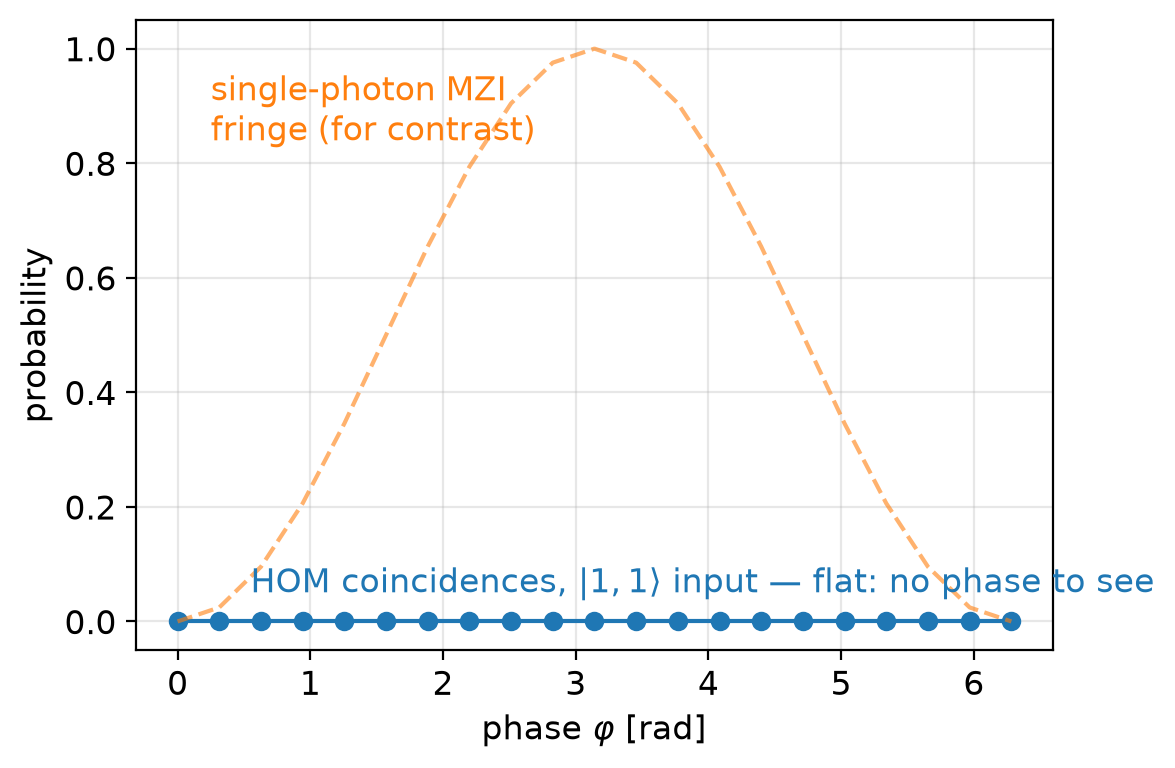

In [13]:
# Worked - Exercise 3 (the fill-in version lives at the bottom)
phis = np.linspace(0, 2 * np.pi, 21)
p_hom = []
for phi in phis:
    c = pcvl.Circuit(2) // (0, pcvl.PS(phi)) // pcvl.BS()  # phase BEFORE the BS
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_hom.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(phis, p_hom, "o-", label=None)
plt.plot(phis, np.sin(phis / 2) ** 2, "--", alpha=0.6,
         label=None)
plt.ylim(-0.05, 1.05)
plt.xlabel(r"phase $\varphi$ [rad]")
plt.ylabel("probability")
plt.annotate("single-photon MZI\nfringe (for contrast)", (0.25, 0.84),
             color="tab:orange")
plt.annotate(r"HOM coincidences, $|1,1\rangle$ input — flat: no phase to see",
             (0.55, 0.05), color="tab:blue")
plt.tight_layout()
plt.show()
# Why flat: the two interfering processes are 'both photons transmitted'
# and 'both photons reflected'. In BOTH processes the same one photon
# passes the phase shifter exactly once, so both amplitudes acquire the
# same factor e^{i phi} - a global phase, invisible in probabilities.
# First-order interference compares paths of ONE photon; HOM compares
# two-photon histories. Different physics, different knobs.

### Interlude · Why quantum-light experiments don't need phase stability

Exercise 3's flat line is not a technicality — it is **number–phase complementarity** doing you an enormous experimental favor.

Photon number and phase are conjugate: $\Delta n\,\Delta\varphi \gtrsim 1$. A Fock state has *definite* $n$ and therefore **no phase at all** — recall Monday's Wigner function of $|4\rangle$: perfectly rotation-symmetric rings, no preferred direction in phase space. If the states you send in carry no phase, and the quantities you record are photon-counting correlations ($g^{(2)}$, coincidences, HOM dips), then *there is no optical phase anywhere in the experiment for you to stabilize.*

The practical consequences, by experiment class:

| experiment | interferes | path stability needed |
|---|---|---|
| MZI / Michelson fringes (Taylor section) | field amplitudes, $e^{i\varphi}$ | $\ll \lambda$ — nanometers, active locking |
| **HBT** (yesterday) | intensities | *none* — that's why Narrabri worked through the atmosphere |
| **HOM** (today) | two-photon amplitudes | only within the **coherence length** (µm–mm) — so the wavepackets overlap, not so phases align |
| homodyne / squeezing (LIGO, Monday) | signal *against a phase reference* | $\ll\lambda$ again — squeezed light *is* phase-structured |

This is why a HOM dip runs unstabilized overnight while a classical white-light interferometer drifts away in seconds, and why photon counting is the natural language of Fock-state optics: by *not* bringing a phase reference (no local oscillator), you measure exactly the phase-free observables the states actually possess. The flip side: the moment your quantum trick involves phase-structured states — squeezing, NOON states (next exercise!) — the interferometric stability bill returns, with interest.

### Visibility · the fine print

Since the HOM dip has no fringes, its quality is a **contrast**, not a phase:

$$\begin{gathered}V = \frac{P_{\rm coinc}^{\max} - P_{\rm coinc}^{\min}}{P_{\rm coinc}^{\max}}\\[3pt]
\xrightarrow{\text{50:50 BS}}\; 1 - 2\,P_{\rm coinc}(0).\end{gathered}$$

Three facts to carry into any lab or paper:

* **$V$ *is* the indistinguishability.** For pure single photons, $V = \mathcal{I} = |\langle\psi_1|\psi_2\rangle|^2$ — the dip is a direct meter of wavepacket overlap (your Exercise 2 showed the linear relation). Mismatch in *any* degree of freedom — arrival time, spectrum, polarization, spatial mode — is a factor $<1$.
* **$V > 1/2$ is the quantum certificate.** Two independent *classical* pulses with randomized relative phase also show a coincidence dip — but at most to half depth: $V_{\rm cl} \le 1/2$. Beating 1/2 plays the same role for two-photon interference that $g^{(2)}(0) < 1$ plays for antibunching. (Yet another reason 50%-ish visibilities in old or noisy experiments prove nothing quantum.)
* **Raw vs. corrected.** Real dips are eaten by multi-photon emission (each source's own $g^{(2)}(0) > 0$!), background counts, and accidentals. Papers quote *raw* visibility (as measured) or *corrected* (backgrounds/multi-photon subtracted) — the gap between them can be tens of percent. When a source claims $V > 95\%$, always check which one it is [Bouchard2021].

## Exercise 4 · The NOON state: a phase measured twice as fast

*In the session: watch and discuss — predict each plot before it appears. The fill-in version to rebuild this yourself is at the bottom of the notebook; the worked cell here is its solution.*


Look again at the HOM output state: $(|2,0\rangle + |0,2\rangle)/\sqrt2$ — "2 photons here, superposed with 2 photons there" (the relative sign depends on the beamsplitter phase convention; Perceval's symmetric BS gives $+$, as you can check by printing the amplitudes). This is a **NOON state** with $N = 2$, and it is a metrology resource: the two-photon amplitude picks up phase at *twice* the single-photon rate ($e^{i2\varphi}$ instead of $e^{i\varphi}$).

**Task:** build the full MZI (`BS`, then `PS(phi)` on the top arm, then `BS`) and send in $|1,1\rangle$ — so the HOM effect creates the NOON state right at the first beamsplitter.

1. Plot the *coincidence* probability $P(|1,1\rangle_{\rm out})$ vs $\varphi$;
2. overlay the single-photon fringe from the Taylor section;
3. extract the fringe period: you should find **half** — oscillation as $\cos 2\varphi$. This is *super-resolution*: the $N$-photon NOON state does phase metrology at the $1/N$ Heisenberg scale rather than the $1/\sqrt{N}$ shot-noise scale. (LIGO's squeezing from Monday is this same idea's more scalable cousin.)

### Does this scale with $N$? Yes — and loss scales faster

Everything you just saw generalizes: $(|N,0\rangle + |0,N\rangle)/\sqrt2$ picks up $e^{iN\varphi}$, the fringe oscillates as $\cos N\varphi$, and the ideal sensitivity reaches the **Heisenberg limit** $\Delta\varphi = 1/N$ instead of shot noise's $1/\sqrt N$. Two things scale against you, though:

* **Making them:** $N = 2$ is the only free lunch — HOM manufactures it at a beamsplitter. There is no deterministic linear-optics route to $N \ge 3$; the optical record, via postselection tricks, is $N = 5$ [Afek2010].
* **Keeping them — loss is the killer, and here is the mechanism.** The NOON state is a superposition of *all $N$ photons up* and *all $N$ photons down*. Now let one photon leak into the environment. That photon came from **one specific arm** — so it is a perfect *which-path tag*. Operator version: loss acts with $\hat a_{\rm up}$, and
$$\hat a_{\rm up}\,\frac{|N,0\rangle + |0,N\rangle}{\sqrt2} \;\propto\; |N\!-\!1,\,0\rangle$$
— the annihilation operator kills the $|0,N\rangle$ branch outright (no photon up there to take), and the superposition collapses to a single branch: **one lost photon, zero coherence, no fringe.** The state only stays a NOON state if *all* $N$ photons survive, probability $\eta^N$ — and detecting it needs an $N$-fold coincidence, also $\eta^N$. The Heisenberg advantage dies exponentially in $N$.

Contrast the classical strategy: a coherent beam is an *eigenstate* of the loss operator, $\hat a|\alpha\rangle = \alpha|\alpha\rangle$ — losing a photon changes nothing and tags nothing, which is exactly *why* coherent light + squeezing is loss-robust. With realistic loss the best any strategy can do is not $1/N$ but a constant factor over shot noise, $\Delta\varphi \ge \sqrt{(1-\eta)/\eta}/\sqrt{\bar N}$ [Demkowicz2012] — Monday's three-rulers table, row two, in one formula. Pick your failure mode: LIGO picked the ruler that survives losing photons.

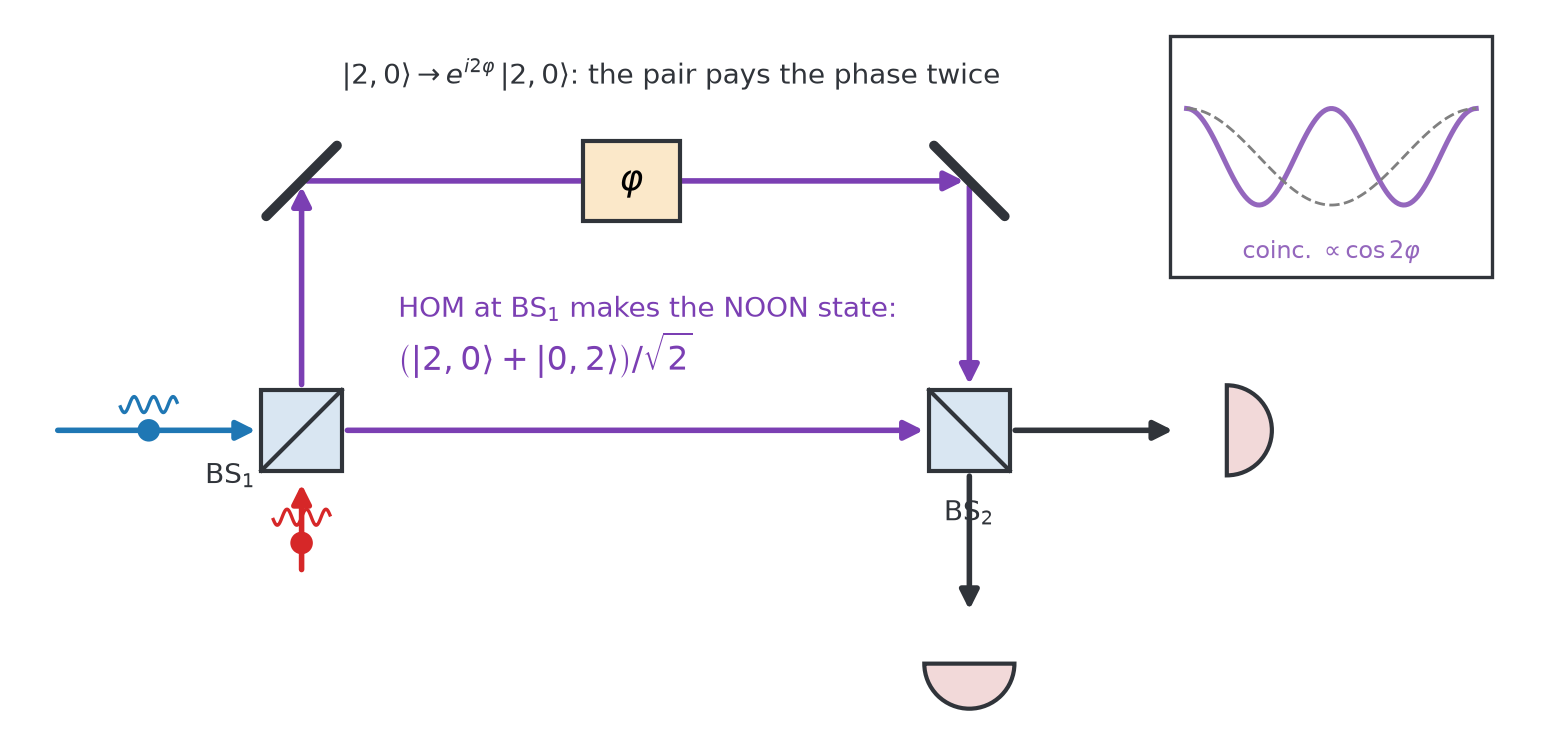

In [14]:
sketches.noon_mzi()

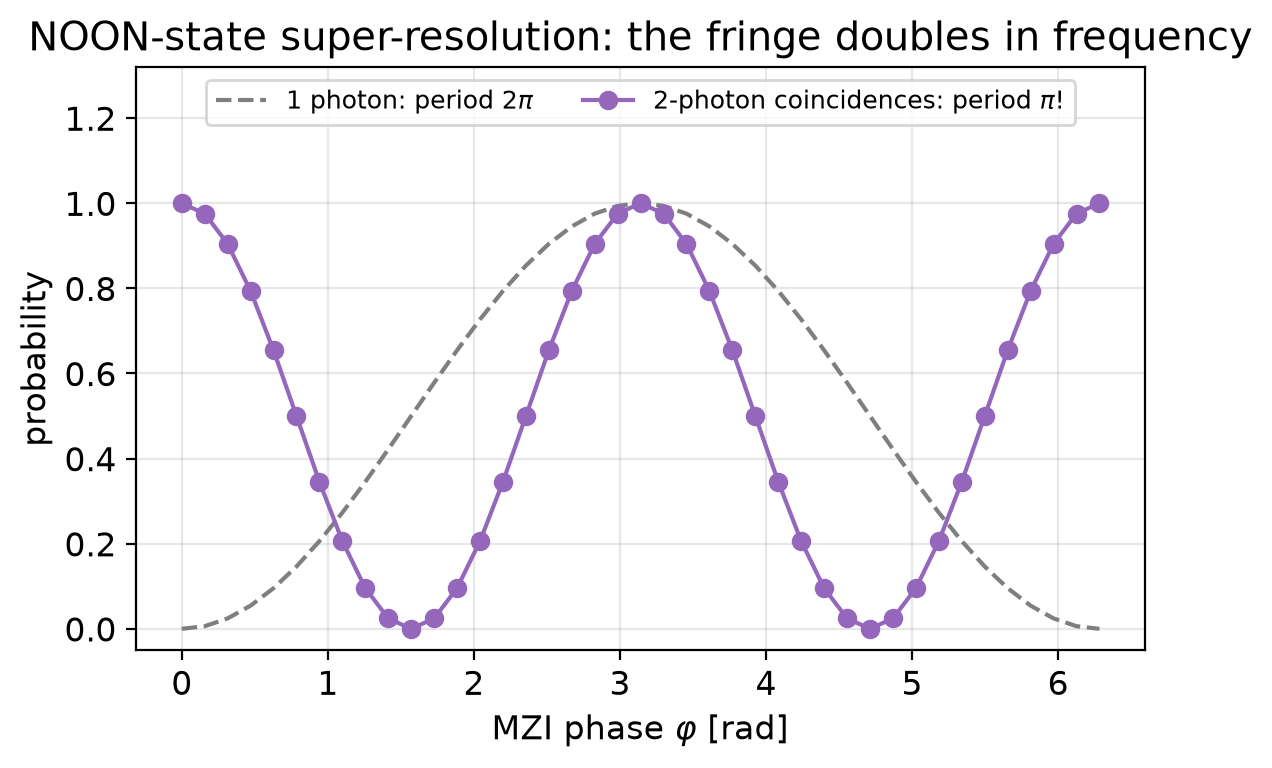

In [15]:
# Worked - Exercise 4 (the fill-in version lives at the bottom)
def mzi(phi: float) -> pcvl.Circuit:
    return pcvl.Circuit(2) // pcvl.BS() // (0, pcvl.PS(phi)) // pcvl.BS()

phis = np.linspace(0, 2 * np.pi, 41)
p_coinc, p_single = [], []
for phi in phis:
    # two photons: NOON state |2,0>+|0,2> forms inside the MZI
    proc = pcvl.Processor("SLOS", mzi(phi))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))
    # one photon, for comparison
    proc1 = pcvl.Processor("SLOS", mzi(phi))
    proc1.with_input(pcvl.BasicState([1, 0]))
    proc1.min_detected_photons_filter(1)
    res1 = pcvl.algorithm.Sampler(proc1).probs()["results"]
    p_single.append(res1.get(pcvl.BasicState([1, 0]), 0.0))

plt.plot(phis, p_single, "--", color="tab:gray",
         label=r"1 photon: period $2\pi$")
plt.plot(phis, p_coinc, "o-", color="tab:purple",
         label=r"2-photon coincidences: period $\pi$!")
plt.xlabel(r"MZI phase $\varphi$ [rad]")
plt.ylabel("probability")
plt.title("NOON-state super-resolution: the fringe doubles in frequency")
plt.ylim(-0.05, 1.32)   # head-room so the legend sits above both curves
plt.legend(loc="upper center", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
# The N=2 NOON state accumulates phase as e^{i 2 phi}: N-photon states
# reach the 1/N Heisenberg limit of phase estimation. Scaling N up is
# brutally hard (loss kills NOON states fast) - which is why LIGO uses
# squeezed light (Monday) rather than NOON states for the same goal.

## If you finish early

* Three-mode challenge: build a *tritter* (3-mode balanced splitter: `pcvl.Circuit(3)` with three `BS`/`PS` — or `pcvl.GenericInterferometer`) and find the three-photon analog of HOM suppression for $|1,1,1\rangle$.
* Sampling realism: replace `probs()` by `sample_count(200)` in your HOM dip and re-extract the visibility — now with shot noise. How many samples per point do you need to certify $V > 0.9$?

## Why this matters (5-minute wrap-up before the break)

**A bit of history first.** Hong, Ou and Mandel built the experiment in 1987 to measure the time interval between two photons with **sub-picosecond** resolution [Hong1987] — decades before electronics could dream of it: the dip width in *delay* is set by the photon coherence time, so a mechanical translation stage becomes a femtosecond clock. Their measured dip: ~100 fs wide (16 µm of beamsplitter travel!), coincidences dropping to a few percent of the wing level — the residual floor set not by the beamsplitter (R/T ≈ 0.95) but by imperfect signal–idler mode overlap at the pinholes. Mode matching has been the experimentalist's tax on HOM visibility ever since. Today the HOM dip is:

* ***the* benchmark of single-photon sources**: the first quantum-dot HOM experiment reached a mean wavepacket overlap of 0.81 [Santori2002]; today's best dots deliver raw two-photon visibilities above 90–95% — the first number to check in any source paper [Bouchard2021];
* **the working principle of every two-qubit gate in linear-optical quantum computing**: photons that don't HOM don't compute. The 2020 boson-sampling quantum advantage [Zhong2020] is, at heart, dozens of photons (43 detected on average) HOM-interfering in a 100-mode interferometer;
* **a metrology resource, twice over**: the NOON fringes of your Exercise 4, and the dip itself as a ruler — broadband photons whose first-order fringes died femtoseconds ago still carry **attosecond-resolution** timing in their coincidence visibility, with zero phase stabilization [Lyons2018] (ruler #3 of Monday's case study); plus a synchronization tool for quantum networks — HOM dips between photons from *different remote sources* certify that network nodes are interferometrically aligned;
* **still a testbed for quantum mechanics itself**: with UB colleagues — including this school's co-organizer Herbert Fotso — we proposed using photon-number states at a beamsplitter to hunt for tiny deviations from Born-rule statistics [Powers2025]. Two mirrors and a piece of glass, and the foundations are still in play.

After the break: we stop *assuming* single photons and *make* them — [`06_Lab_HeraldedFockStates`](06_Lab_HeraldedFockStates.ipynb).

---
---

# Sample solutions

**No peeking during the session.**

---

# Take-home: rebuild the four experiments yourself

The same four cells, with the physics lines blanked out — the worked
versions above are the solutions. Rebuild them without peeking, then
compare.

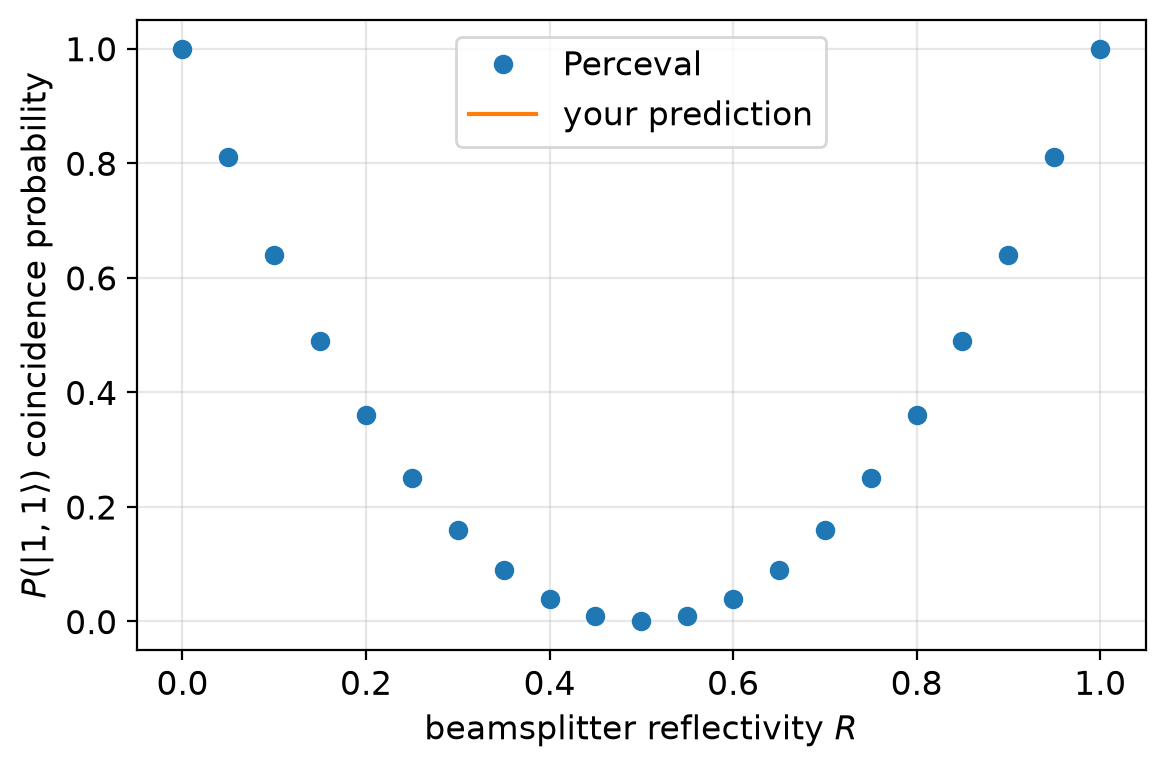

In [16]:
# YOUR CODE HERE - Exercise 1
# The sweep machinery is wired - your part is the physics.
R_values = np.linspace(0, 1, 21)          # <-- the reflectivity grid

p_coinc = []
for R in R_values:
    c = pcvl.Circuit(2) // pcvl.BS(theta=pcvl.BS.r_to_theta(R))
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))

# Your prediction from the two interfering amplitudes (formula above).
# Replace the NaNs with a function of R_values; it should land on the dots.
theory = np.full_like(R_values, np.nan)   # <-- your line here

plt.plot(R_values, p_coinc, "o", label="Perceval")
plt.plot(R_values, theory, "-", label="your prediction")
plt.xlabel("beamsplitter reflectivity $R$")
plt.ylabel(r"$P(|1,1\rangle)$ coincidence probability")
plt.legend()
plt.tight_layout()
plt.show()


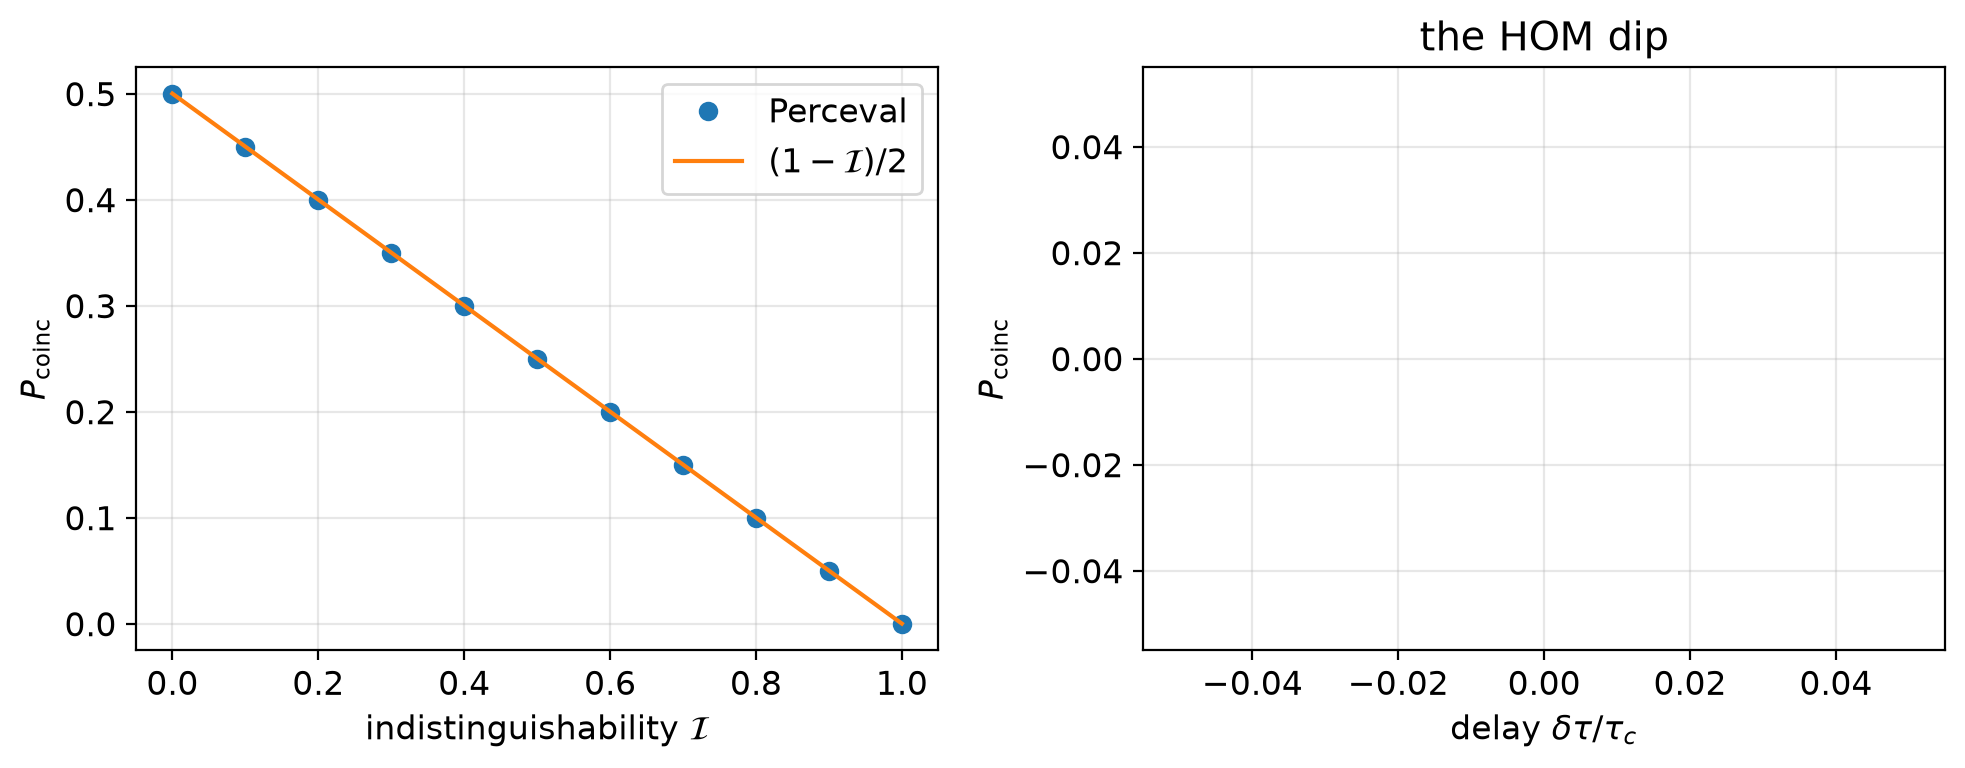

dip visibility: fill in I_of_delay (part 2) first


In [17]:
# YOUR CODE HERE - Exercise 2
# Part 1 (wired): coincidences vs indistinguishability via the noise model.
I_values = np.linspace(0, 1, 11)
circuit = pcvl.Circuit(2) // pcvl.BS()
p_coinc = []
for I in I_values:
    proc = pcvl.Processor("SLOS", circuit,
                          noise=pcvl.NoiseModel(indistinguishability=I))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(sum(p for st, p in res.items()
                       if st[0] == 1 and st[1] == 1))
p_coinc = np.array(p_coinc)

# Part 2 - your input: the Gaussian mapping I(delta_tau) from the text.
delay = np.linspace(-3, 3, 61)                # delta_tau / tau_c
I_of_delay = np.full_like(delay, np.nan)      # <-- replace the NaNs
p_dip = np.interp(I_of_delay, I_values, p_coinc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(I_values, p_coinc, "o", label="Perceval")
ax1.plot(I_values, (1 - I_values) / 2, "-", label=r"$(1-\mathcal{I})/2$")
ax1.set_xlabel(r"indistinguishability $\mathcal{I}$")
ax1.set_ylabel(r"$P_{\rm coinc}$")
ax1.legend()
ax2.plot(delay, p_dip, "-")
ax2.set_xlabel(r"delay $\delta\tau / \tau_c$")
ax2.set_ylabel(r"$P_{\rm coinc}$")
ax2.set_title("the HOM dip")
plt.tight_layout()
plt.show()

# Part 3 (wired): the visibility of your dip.
if np.isnan(I_of_delay).all():
    print("dip visibility: fill in I_of_delay (part 2) first")
else:
    V = (np.nanmax(p_dip) - np.nanmin(p_dip)) / np.nanmax(p_dip)
    print(f"dip visibility V = {V:.3f}")


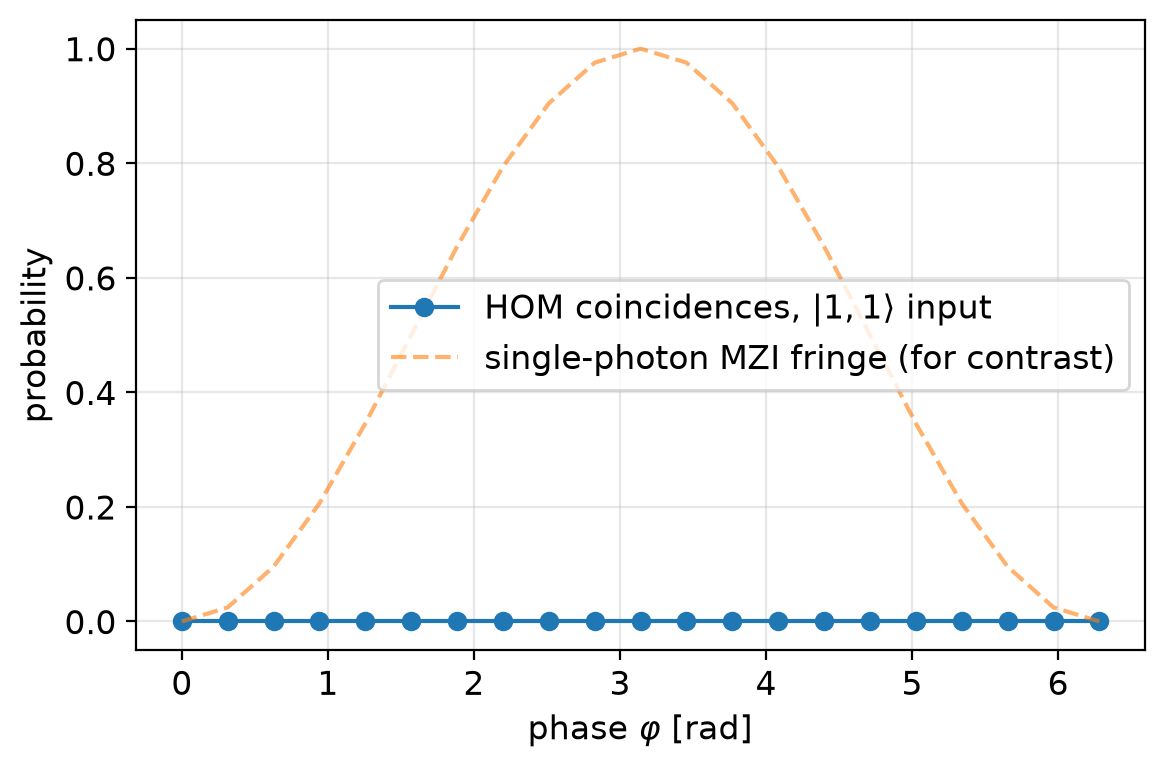

In [18]:
# YOUR CODE HERE - Exercise 3
# The sweep is wired. Your input: put a phase shifter in ONE input arm,
# BEFORE the beamsplitter. Syntax:  // (0, pcvl.PS(phi))  inserts PS(phi)
# on mode 0. Then look at the plot - and explain it.
phis = np.linspace(0, 2 * np.pi, 21)
p_hom = []
for phi in phis:
    c = pcvl.Circuit(2) // pcvl.BS()          # <-- add the phase shifter here
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_hom.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(phis, p_hom, "o-", label=r"HOM coincidences, $|1,1\rangle$ input")
plt.plot(phis, np.sin(phis / 2) ** 2, "--", alpha=0.6,
         label="single-photon MZI fringe (for contrast)")
plt.ylim(-0.05, 1.05)
plt.xlabel(r"phase $\varphi$ [rad]")
plt.ylabel("probability")
plt.legend()
plt.tight_layout()
plt.show()


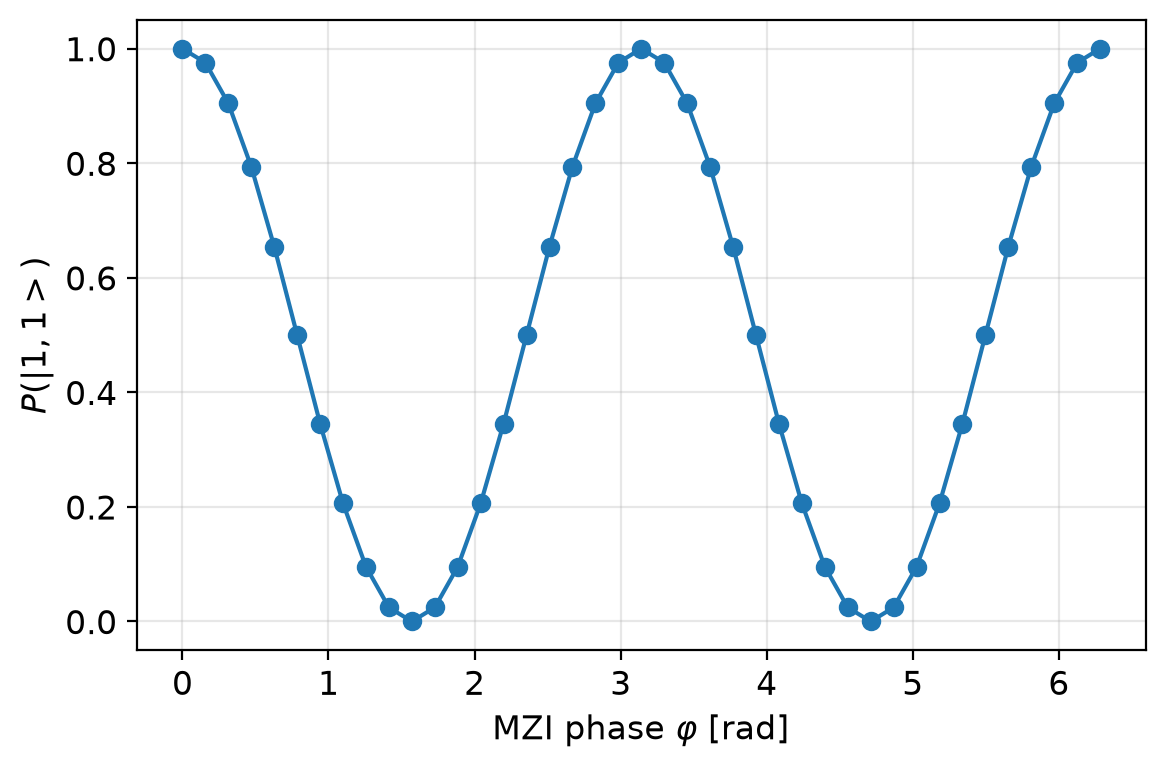

In [19]:
# YOUR CODE HERE - Exercise 4
# The MZI and the sweep are wired. Your inputs: the input state and the
# matching detected-photon filter. Run the cell twice -
#   |1,1> with filter 2  (the NOON run), then
#   |1,0> with filter 1  (the single-photon comparison) -
# and compare the fringe periods.
def mzi(phi):
    return pcvl.Circuit(2) // pcvl.BS() // (0, pcvl.PS(phi)) // pcvl.BS()

input_state = pcvl.BasicState([1, 1])     # <-- the state you send in
n_min = 2                                 # <-- filter: match the photon number!

phis = np.linspace(0, 2 * np.pi, 41)
p = []
for phi in phis:
    proc = pcvl.Processor("SLOS", mzi(phi))
    proc.with_input(input_state)
    proc.min_detected_photons_filter(n_min)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p.append(res.get(input_state, 0.0))

plt.plot(phis, p, "o-")
plt.xlabel(r"MZI phase $\varphi$ [rad]")
plt.ylabel(f"$P({input_state})$")
plt.tight_layout()
plt.show()
# By what factor do the two periods differ - and what in the NOON state
# causes that factor?
